#Predicting Student Mental Health Score from Social Media Usage
Problem: We're predicting a student's Mental_Health_Score (a continuous score from ~3 to ~10) using their social media habits, study time, sleep, physical activity, and stress level. This is a regression problem since the target is a number, not a category.

Dataset: Student_Social_Media_And_Mental_Health_Impact.csv — 5,000 students, 13 columns covering demographics (Age, Gender, Country), platform usage (Avg_Daily_Usage_Hours, Daily_Unlocks, Most_Used_Platform), lifestyle (Study_Hours, Sleep_Hours_Per_Night, Physical_Activity_Hours), and Stress_Level.

In [59]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
#Loading dataset
df=pd.read_csv("/content/Student Social Media And Mental Health Impact.csv")

In [61]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [62]:
df.shape #rows=5000, columns=13

(5000, 13)

In [63]:
df.isnull().sum() #no null values

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [64]:
df.duplicated().sum() #2 duplicates values

np.int64(2)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [66]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


Readings: Problem in Physical_Activity_Hours column. -0.4 Min. Value. Hours can not be negative

#EDA

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

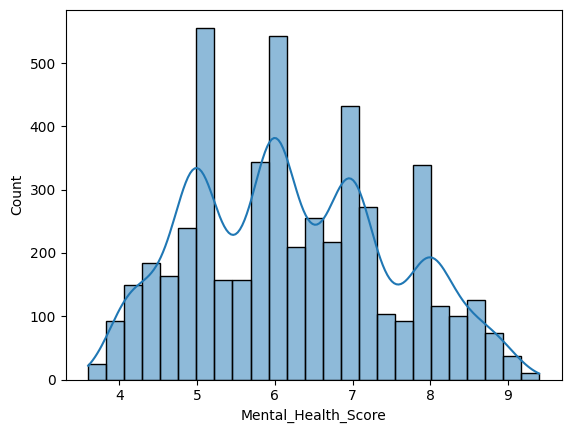

In [67]:
#Distribution of the target (Mental_Health_Score)

sns.histplot(data=df['Mental_Health_Score'],kde=True)

<Axes: >

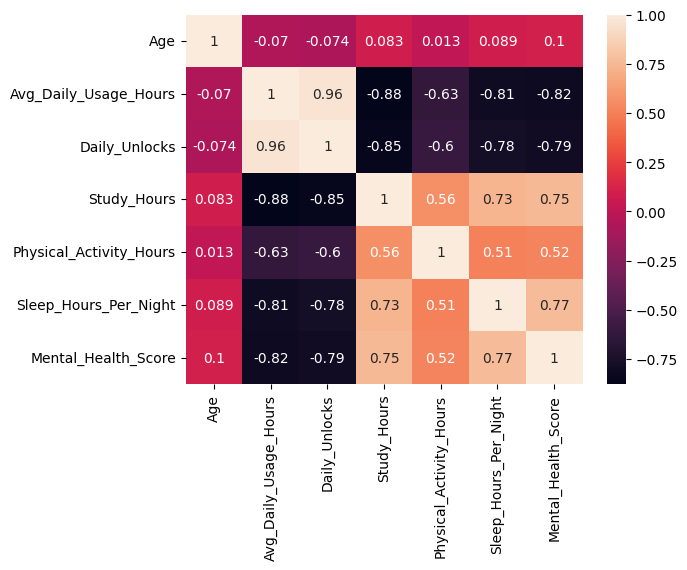

In [68]:
#Correlation Heatmap: Which numeric features actually move together with the target?

sns.heatmap(data=df.corr(numeric_only=True),annot=True)

In [69]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

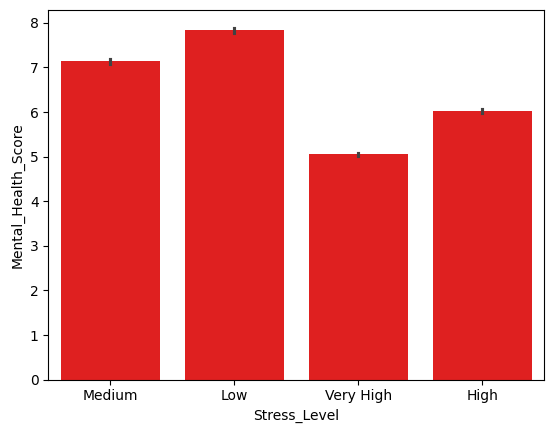

In [70]:
#stress vs mental_health_score

sns.barplot(data=df,x="Stress_Level",y="Mental_Health_Score",color='red')

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

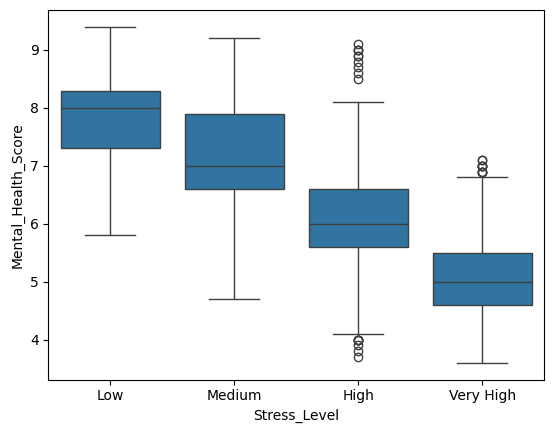

In [71]:
#outliers in high and very high

stress_order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level', y='Mental_Health_Score',data=df, order=stress_order)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

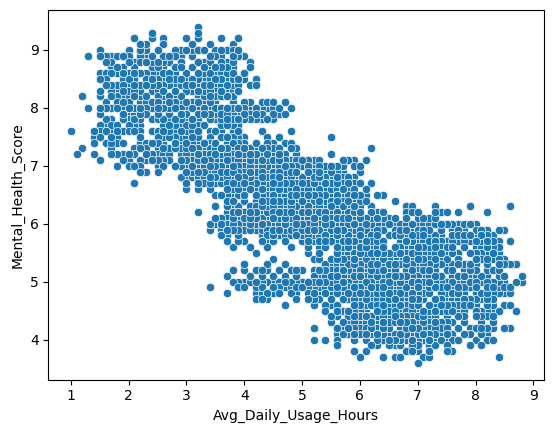

In [72]:
#Daily Usage Hours vs Mental Health Score: High usage_hours have low mental health
sns.scatterplot(data=df,x='Avg_Daily_Usage_Hours',y='Mental_Health_Score')

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

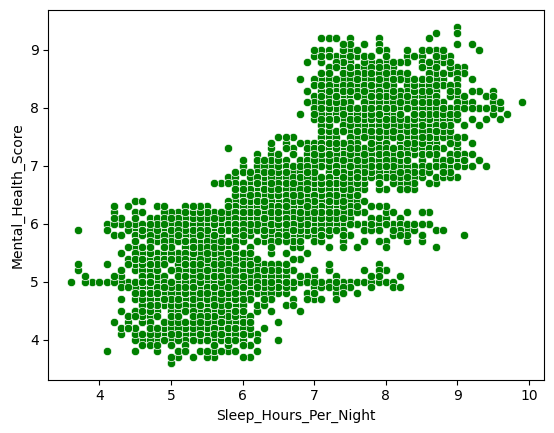

In [73]:
#Sleep Hours vs Mental Health Score: +ve relation

sns.scatterplot(data=df,x='Sleep_Hours_Per_Night',y='Mental_Health_Score',color='Green')

<Axes: xlabel='count', ylabel='Most_Used_Platform'>

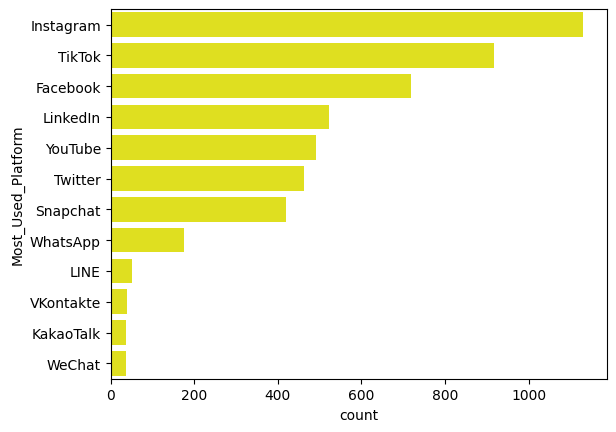

In [74]:
#Most used social_media_platforms?

sns.countplot(y=df['Most_Used_Platform'],color='yellow',order=df['Most_Used_Platform'].value_counts().index)

#Checking Outliers

In [75]:
#Total outliers= 24

num_features = df.select_dtypes(include='number') #Dtype= int64 or float64
Q1  = num_features.quantile(0.25)
Q3  = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


#DATA CLEANING

In [76]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [77]:
#Drop duplicates
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [78]:
#Converting negative and unrealestic values to real: Ex- -ve Hours

df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

Why clip(lower=0) and not dropping the row?
 The rest of that student's data (age, study hours, stress level, etc.) is still valid and useful — throwing away the whole row over one bad value wastes good data. Clipping caps the impossible value at the nearest realistic one (0 hours) without discarding everything else about that student.

#Skewness

What skewness is: a measure of how lopsided a numeric column's distribution is. A value near 0 means roughly symmetric (bell-shaped); a large positive or negative value means the data leans heavily to one side, with a long tail.

Why it matters: models like Linear Regression assume features are roughly well-behaved. A heavily skewed column (think: a long tail of extreme values) can quietly drag the model's predictions in that direction. Tree-based models like Random Forest don't care about skew — but since we're also training a Linear Regression baseline, it's worth fixing.

In [79]:

num_columns=df.select_dtypes(include='number')
num_columns.skew()

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


#Feature engineering

Country has 111 unique values in this dataset — one-hot encoding that directly would add 110+ mostly-empty columns, which hurts the model far more than it helps (this is called high cardinality).
Dropping Country entirely throws away real signal — a student's country genuinely correlates with things like internet access, culture, and sleep norms.
The fix: keep the top 10 most frequent countries as their own category, and bucket everything else into "Other". We keep the signal that matters and lose the noise that doesn't.

In [80]:
top_countries=df['Country'].value_counts().index[:11].tolist()

In [81]:
def group_countries(Country):
  if Country in top_countries:
    return Country
  else:
    return 'Other'

In [82]:
df['grouped_countries']=df['Country'].apply(group_countries)

In [83]:
df['grouped_countries'].value_counts()

,count
grouped_countries,
Other,3148
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Turkey,94
Mexico,94


In [84]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,grouped_countries
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other


Result: we went from 111 raw categories down to 11 manageable ones (10 countries + "Other").

#Data Encoding

Stress_Level → Ordinal Encoding.

Gender, Academic_Level, Most_Used_Platform, Purpose_Of_Use, Country_Grouped → One-Hot Encoding.

#Train-test split

1. Load dataset
2. Separate features (X) and target (y)
3. Train-Test Split
4. Create preprocessing pipelines
    - Missing value imputation
    - Encoding
    - Scaling
5. Combine preprocessing using ColumnTransformer
6. Fit the preprocessor on X_train
7. Transform X_train and X_test
8. Train the model on processed X_train
9. Predict on processed X_test
10. Evaluate the model

In [85]:
from sklearn.model_selection import train_test_split

skewed_col         = ['Study_Hours']
other_numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours",
                      "Sleep_Hours_Per_Night"]
ordinal_col        = ['Stress_Level']
nominal_col         = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "grouped_countries"]


feature_col = skewed_col + other_numeric_cols + ordinal_col + nominal_col
x = df[feature_col] #I/P features
y = df['Mental_Health_Score']  #target feature

X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.30,random_state=42)


#Data Preprocessing using ColumnTransformer

Creating multiple pipelines

In [86]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,FunctionTransformer

skewed_pipeline = Pipeline(steps=[
    ("log_transformation",FunctionTransformer(np.log1p)),
    ("scale", StandardScaler()) ])

Plain_numeric_pipeline=Pipeline(steps=[("scale",StandardScaler())])

Ordinal_pipeline=Pipeline(steps=[ ("OE",OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']])) ])

Nominal_pipeline=Pipeline(steps=[("OHE",OneHotEncoder(handle_unknown="ignore"))])


1. Adding columns and Pipelines to Column_transformer.
2. Combine Pipelines using ColumnTransformer

In [87]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ("Skewed_pipeline",skewed_pipeline,skewed_col),
    ("PN_pipeline", Plain_numeric_pipeline,other_numeric_cols ),
    ("OE", Ordinal_pipeline,ordinal_col),
    ("OHE",Nominal_pipeline,nominal_col)
])

#Model building

1. Baseline model -- Linear regression

In [88]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#creating linear_regression pipeline
lr_pipeline=Pipeline([("preprocessing",preprocessor),
                      ("LR",LinearRegression())])

#fitting lr_pipeline on training data
lr_pipeline.fit(X_train,Y_train)

#predicting values
lr_preds_test  = lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)

#performance valuation
lr_r2_testing  = r2_score(Y_test,lr_preds_test) #testing accuracy
lr_r2_training = r2_score(Y_train,lr_preds_train) #training accuracy
lr_mae         = mean_absolute_error(Y_test, lr_preds_test) #testing mae score

print(f"Accuracy of Training {lr_r2_training}")
print(f"Accuracy of Testing {lr_r2_testing}")
print(f'MAE {lr_mae}')



Accuracy of Training 0.7284451141767213
Accuracy of Testing 0.7431949512902988
MAE 0.5302565031464506


2. Random Forest (default settings)

In [89]:
from sklearn import pipeline
from sklearn.ensemble import RandomForestRegressor

rf_pipeline=Pipeline([("preprocessing",preprocessor),("random_forest",RandomForestRegressor(random_state=42))])

#fitting rf_pipeline on training data
rf_pipeline.fit(X_train,Y_train)

#predicting values
rf_preds_test  = rf_pipeline.predict(X_test)
rf_preds_train = rf_pipeline.predict(X_train)

#performance valuation
rf_r2_testing  = r2_score(Y_test,rf_preds_test) #testing accuracy
rf_r2_training = r2_score(Y_train,rf_preds_train) #training accuracy
rf_mae         = mean_absolute_error(Y_test, rf_preds_test) #testing mae score


print(f"Accuracy of Training random_forest {rf_r2_training}")
print(f"Accuracy of Testing random_forest {rf_r2_testing}")
print(f'MAE random_forest{rf_mae}')

Accuracy of Training random_forest 0.9811530095291167
Accuracy of Testing random_forest 0.8803226732431098
MAE random_forest0.3423140666666668


3. Random forest with hyperparameter tunning

In [90]:
from sklearn.model_selection import RandomizedSearchCV

parameters = {
    'random_forest__n_estimators'       : [100,200,300,400,500],
    'random_forest__max_depth'         : [5,10,15,20,25,30,35,40,45,50],
    'random_forest__min_samples_split' : [2,5,10,15,20,25],
    'random_forest__min_samples_leaf'  : [1,2,4,5,6,10]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=parameters,
    n_iter = 20,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs =-1
)

random_search.fit(X_train,Y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('Skewed_pipeline',
                                                                               Pipeline(steps=[('log_transformation',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('PN_pipeline',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unlocks'...
                                                                                'grouped_countries'])])),
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'random_forest__max_depth': [5, 10, 15,
                                                                     20, 25, 30,
                                                                     35, 40, 45,
                                                                     50],
                                        'random_forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4,
                                                                            5,
                                                                            6,
                                                                            10],
                                        'random_forest__min_samples_split': [2,
                                                                             5,
                                                                             10,
                                                                             15,
                                                                             20,
                                                                             25],
                                        'random_forest__n_estimators': [100,
                                                                        200,
                                                                        300,
                                                                        400,
                                                                        500]},
                   random_state=42, scoring='r2')

In [91]:
random_search.best_params_

{'random_forest__n_estimators': 200,
 'random_forest__min_samples_split': 2,
 'random_forest__min_samples_leaf': 1,
 'random_forest__max_depth': 30}

In [92]:

rf_best_pipeline = random_search.best_estimator_
rf_best_preds    = rf_best_pipeline.predict(X_test)

print(f"R2 Score for random forest after hyperparameter tuning {r2_score(Y_test, rf_best_preds)}")
print(f"MAE Score for random forest after hyperparameter tuning {mean_absolute_error(Y_test, rf_best_preds)}")

R2 Score for random forest after hyperparameter tuning 0.8816037783814463
MAE Score for random forest after hyperparameter tuning 0.3411542264945839


#Model Evaluation

In [93]:
from sklearn.metrics import mean_squared_error

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(Y_test,lr_preds_test ))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(Y_test, rf_preds_test))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(Y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(Y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(Y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(Y_test, rf_tuned_preds)


# Creating a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)

                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.743195     0.728445  0.530257  0.671600
1  Random Forest (default)  0.880323     0.981153  0.342314  0.458474
2    Random Forest (tuned)  0.881604     0.981811  0.341154  0.456014


#Findings:
Random forest with tuning is performing slightly better than random forest with default settings but i am choosing Random forest(default) as my main model for predictions because it is computaionally less expensive and faster.


**Random forest(default):**
1. Testing R2_score: 88.03%
2. Training R2_score: 98.11%
3. MAE: 34.23%
4. RMSE: 45.84%

#Save Model

In [94]:
import joblib
joblib.dump(rf_pipeline,"Mental_health_model.pkl")

['Mental_health_model.pkl']